In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=32
sfreq=64
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.1, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014008()
subject, session, run = 1, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.797 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


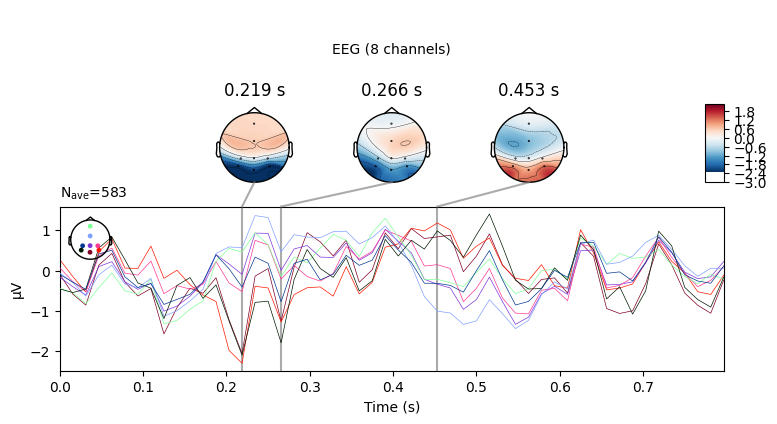

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')

X_train = tl.tensor(epochs_train.get_data().astype(np.float32))
y_train = labels_train
X_test = tl.tensor(epochs_test.get_data().astype(np.float32))
y_test = labels_test

X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]

In [47]:
from hoda.hoda import BTTDA

block_rank=2
hoda = BTTDA(
    block_rank=block_rank,
    hoda_params=dict(
        max_iter=128,
        rank=(1,1),
        tol=1e-6,
        initialize ='svd',
        verbose=True,
        shrinkage=('oas', 'oas'),
        toeplitz=(1,),
        solver='ratio_svd'
    )
)

hoda.fit(X_train,y_train)

[0/128]  shrinkage=0.0012  shrinkage=0.0608  step=1.3868e+00
[1/128]  shrinkage=0.0014  shrinkage=0.0975  step=1.3033e+00
[2/128]  shrinkage=0.0013  shrinkage=0.1002  step=1.4185e+00
[3/128]  shrinkage=0.0016  shrinkage=0.0797  step=1.1776e+00
[4/128]  shrinkage=0.0015  shrinkage=0.0902  step=2.1435e-01
[5/128]  shrinkage=0.0016  shrinkage=0.0912  step=1.1627e-01
[6/128]  shrinkage=0.0015  shrinkage=0.0965  step=6.5297e-02
[7/128]  shrinkage=0.0016  shrinkage=0.0989  step=3.4839e-02
[8/128]  shrinkage=0.0016  shrinkage=0.1020  step=2.6690e-02
[9/128]  shrinkage=0.0016  shrinkage=0.1032  step=1.6095e-02
[10/128]  shrinkage=0.0016  shrinkage=0.1047  step=1.4345e-02
[11/128]  shrinkage=0.0016  shrinkage=0.1053  step=9.4491e-03
[12/128]  shrinkage=0.0016  shrinkage=0.1060  step=8.3911e-03
[13/128]  shrinkage=0.0016  shrinkage=0.1062  step=5.6412e-03
[14/128]  shrinkage=0.0016  shrinkage=0.1065  step=4.9040e-03
[15/128]  shrinkage=0.0016  shrinkage=0.1066  step=3.3020e-03
[16/128]  shrinkag

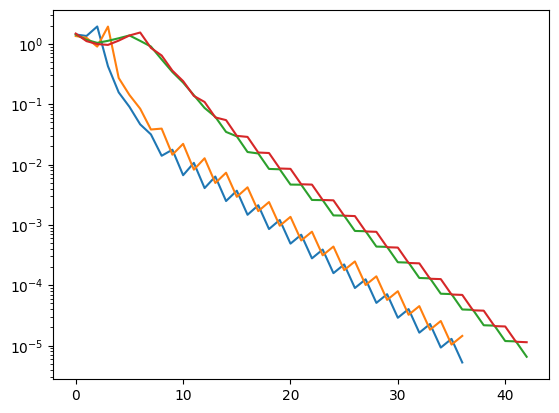

In [48]:
import cupy

for b in range(block_rank):
    plt.semilogy(cupy.asnumpy(hoda.blocks_[b].updates_))
plt.show()

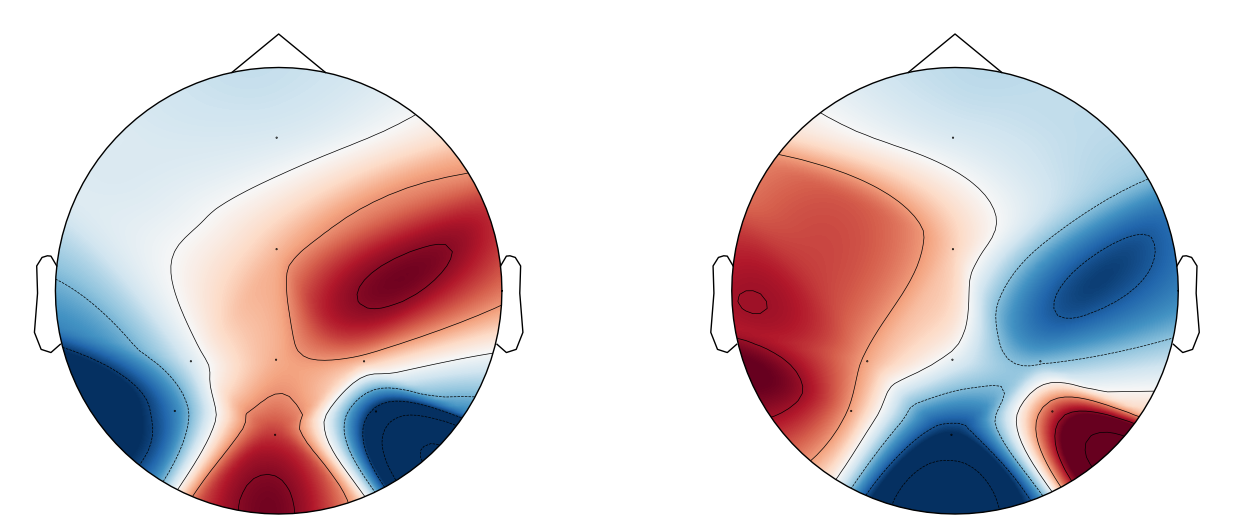

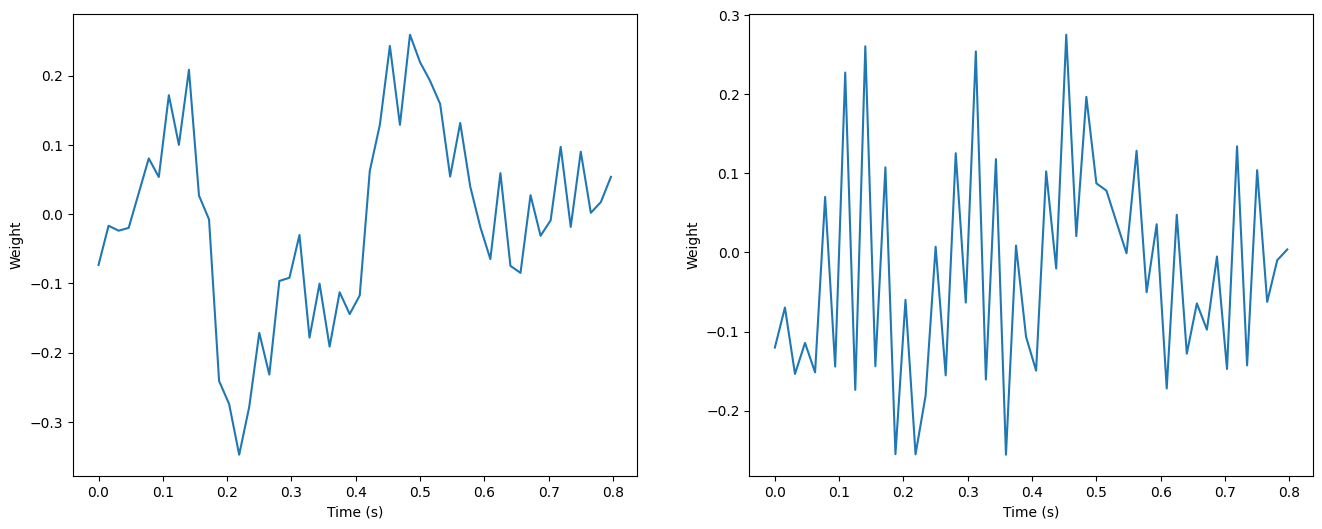

In [49]:
fig, axs = plt.subplots(1,block_rank, figsize=(16,6))
for i in range(block_rank):
    w = cupy.asnumpy(hoda.blocks_[i].projs_[0].squeeze())
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
fig, axs = plt.subplots(1,block_rank, figsize=(16,6))
for i in range(block_rank):
    w = cupy.asnumpy(hoda.blocks_[i].projs_[1].squeeze())
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')


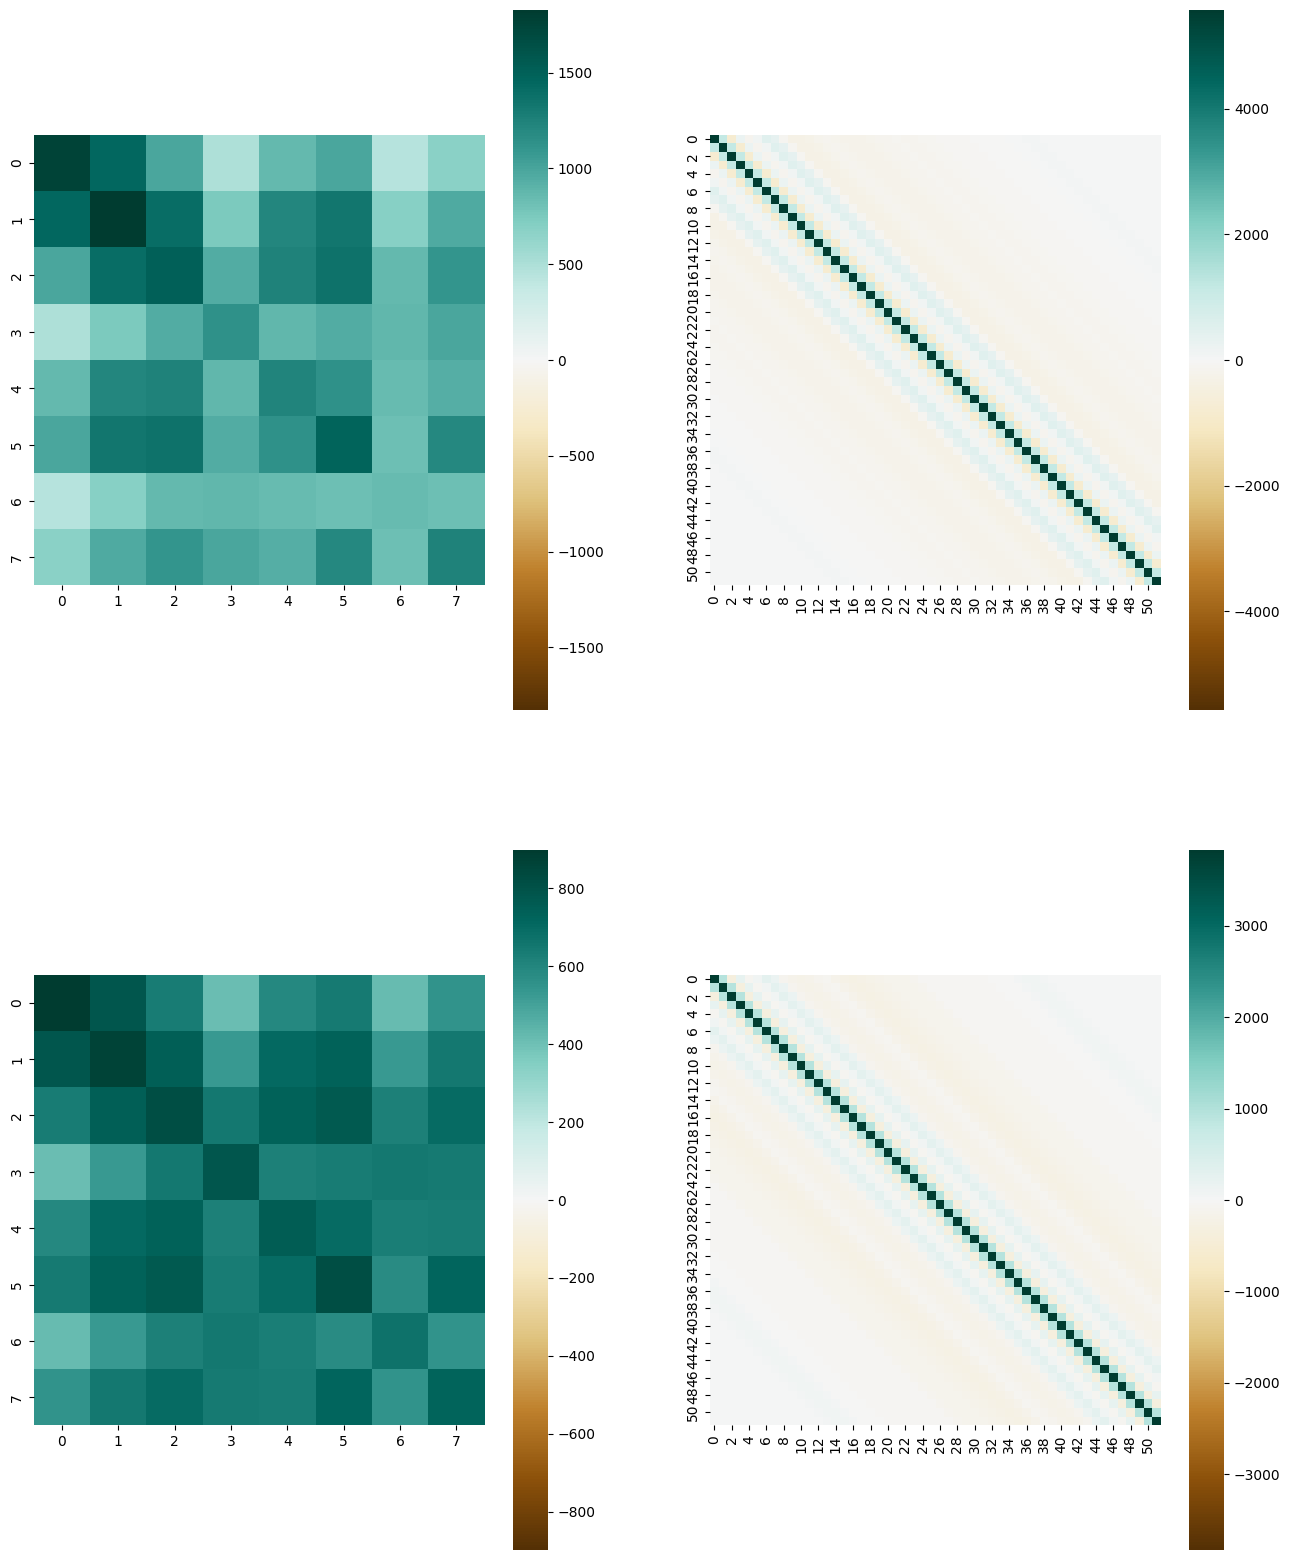

In [50]:
fig, axs = plt.subplots(block_rank,2, figsize=(16,20))
for b in range(block_rank):
    for k in range(2):
        cov = cupy.asnumpy(hoda.blocks_[b].scatter_w_[k])
        vmax = np.max(np.abs(cov))
        sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[b,k])
        axs[b,k].set_aspect('equal')

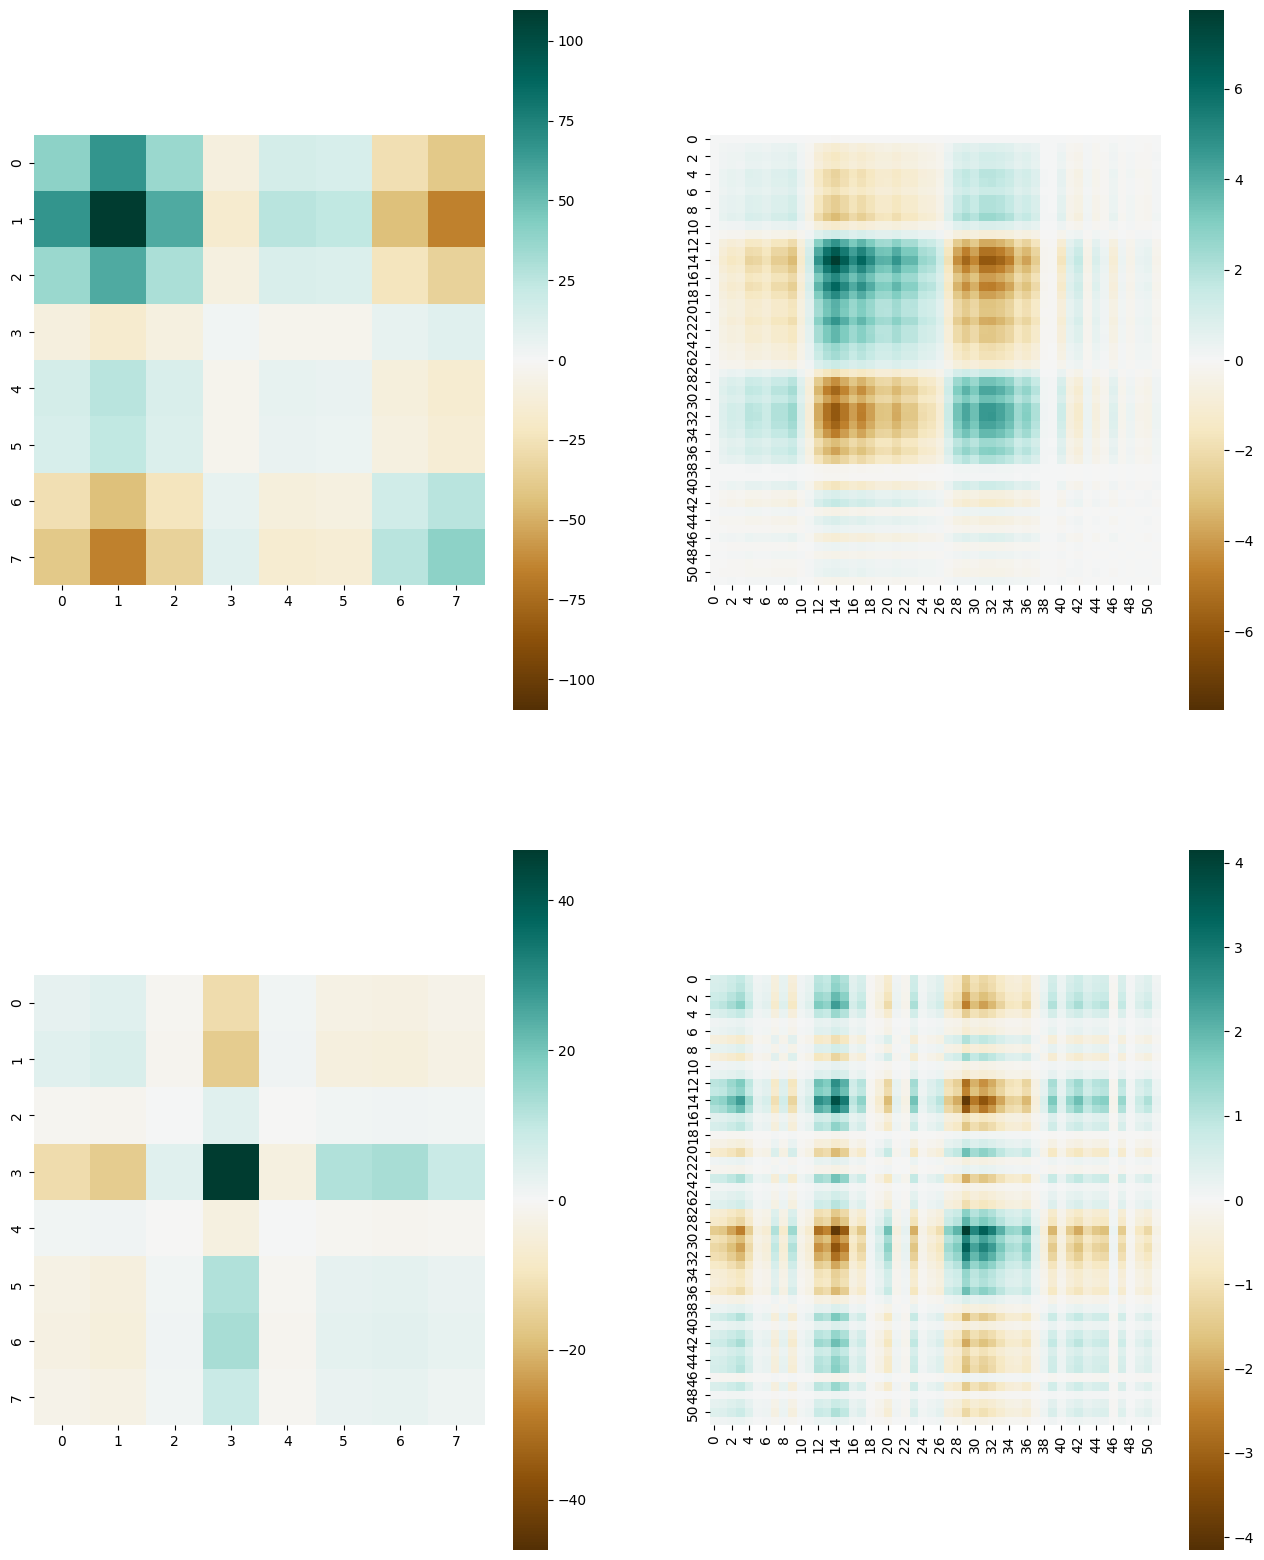

In [51]:
fig, axs = plt.subplots(block_rank,2, figsize=(16,20))
for b in range(block_rank):
    for k in range(2):
        cov = cupy.asnumpy(hoda.blocks_[b].scatter_b_[k])
        vmax = np.max(np.abs(cov))
        sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[b,k])
        axs[b,k].set_aspect('equal')

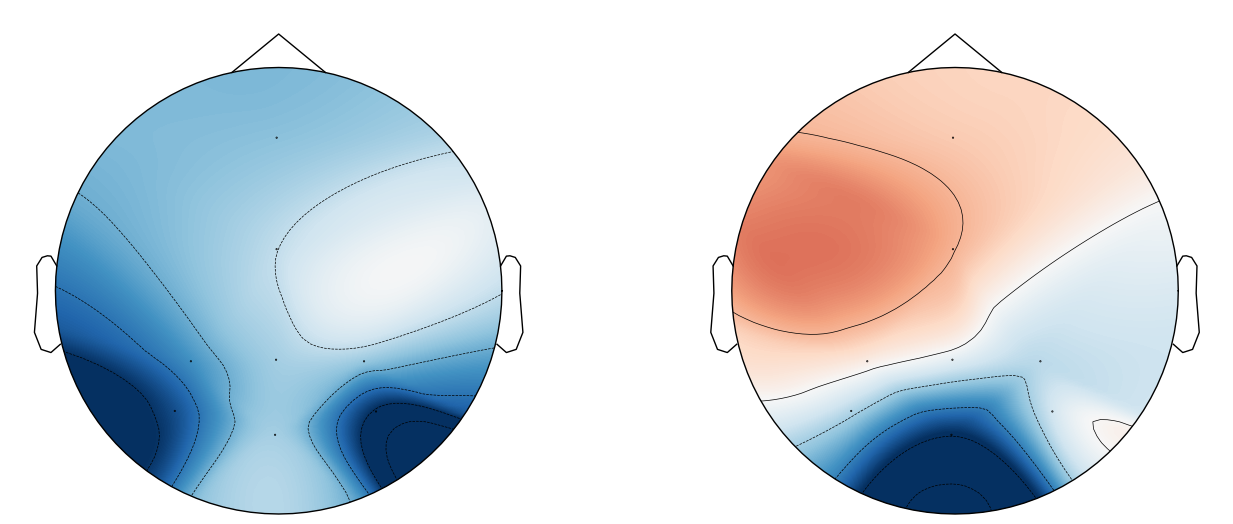

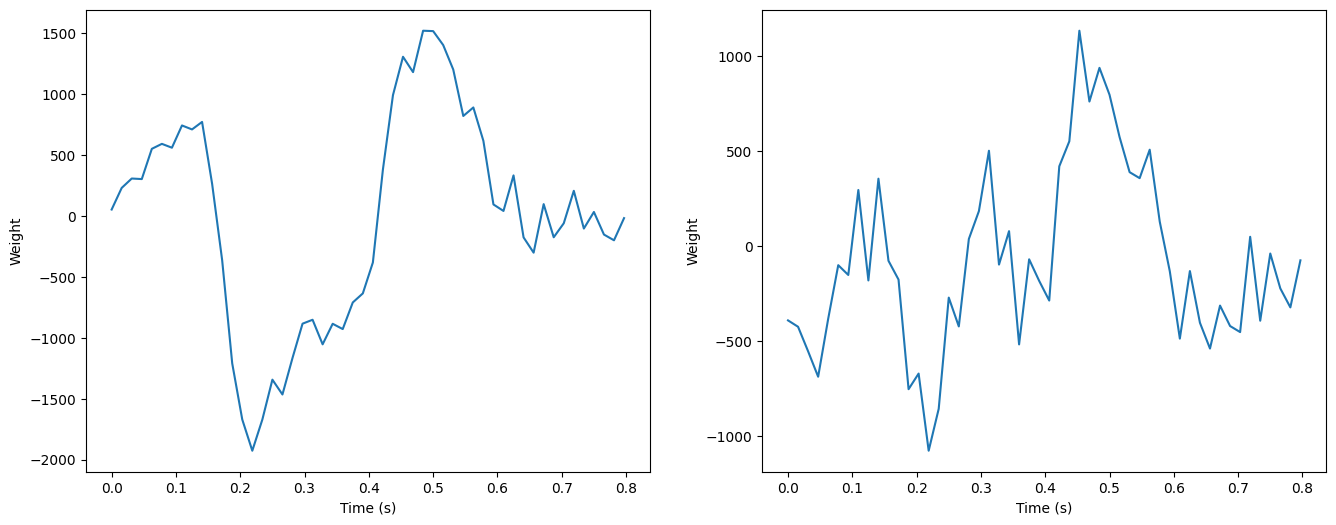

In [52]:
fig, axs = plt.subplots(1,block_rank, figsize=(16,6))
for i in range(block_rank):
    w = cupy.asnumpy(hoda.blocks_[b].scatter_w_[0] @ hoda.blocks_[i].projs_[0].squeeze())
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
fig, axs = plt.subplots(1,block_rank, figsize=(16,6))
for i in range(block_rank):
    w = cupy.asnumpy(hoda.blocks_[b].scatter_w_[1] @ hoda.blocks_[i].projs_[1].squeeze())
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')

In [53]:
Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))

Xt_train = Xt_train.reshape((Xt_train.shape[0],-1))
Xt_test = Xt_test.reshape((Xt_test.shape[0],-1))

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.svm import SVC

classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)


LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

In [55]:
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()
f1 = feature_order[0]
f2 = feature_order[1]

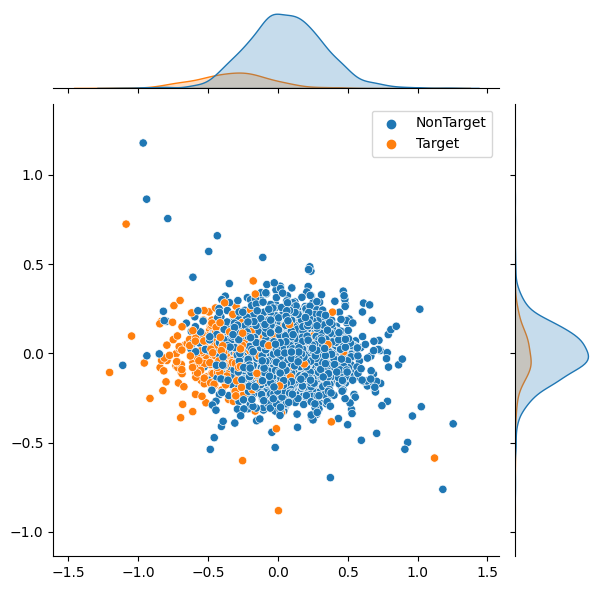

In [56]:
import seaborn as sns

g = sns.jointplot(x=Xt_train[:,f1],y=Xt_train[:,f2], hue=y_train)

In [57]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.8412571428571427

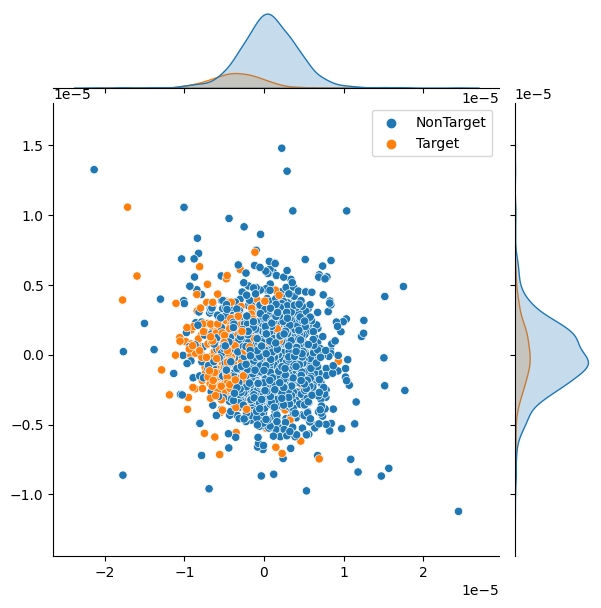

In [58]:
g = sns.jointplot(x=Xt_test[:,f1],y=Xt_test[:,f2], hue=y_test)

In [59]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.8010351020408164